In [2]:
import numpy as np
from scipy.signal import sawtooth, butter, lfilter
import wave

In [3]:
import matplotlib.pyplot as plt

In [19]:
# Constants
SAMPLE_RATE = 44100  # Samples per second
DURATION = 1.0       # Duration of each note in seconds
FREQUENCIES = {'C4': 261.63, 'E4': 329.63, 'G4': 392.00}  # Frequencies of notes in Hz
NOTE_DURATIONS = {'C4': 1.0, 'E4': 0.5, 'G4': 1.5}
AMPLITUDE = 0.5      # Amplitude of the wave (0.0 to 1.0)

# ADSR envelope parameters
ATTACK_TIME = 0.1
DECAY_TIME = 0.1
SUSTAIN_LEVEL = 0.7
RELEASE_TIME = 0.2

In [20]:
def generate_sawtooth_wave(frequency, duration, sample_rate):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    wave = sawtooth(2 * np.pi * frequency * t)
    return wave

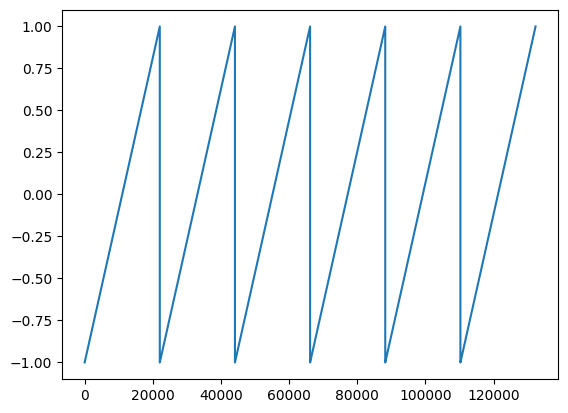

In [21]:
plt.plot(generate_sawtooth_wave(2.0, 3.0, SAMPLE_RATE))

In [22]:
def apply_adsr_envelope(wave, sample_rate, attack, decay, sustain, release):
    total_samples = len(wave)
    attack_samples = int(attack * sample_rate)
    decay_samples = int(decay * sample_rate)
    release_samples = int(release * sample_rate)
    sustain_samples = total_samples - attack_samples - decay_samples - release_samples

    if sustain_samples < 0:
        raise ValueError("Total duration is too short for the ADSR envelope!")

    envelope = np.concatenate([
        np.linspace(0, 1, attack_samples),  # Attack
        np.linspace(1, sustain, decay_samples),  # Decay
        np.full(sustain_samples, sustain),  # Sustain
        np.linspace(sustain, 0, release_samples)  # Release
    ])

    return wave * envelope[:total_samples]

In [23]:
def save_wave_to_file(filename, wave_data, sample_rate):
    wave_data = (wave_data * 32767).astype(np.int16)  # Convert to 16-bit PCM
    with wave.open(filename, 'w') as wf:
        wf.setnchannels(1)  # Mono
        wf.setsampwidth(2)  # 16 bits
        wf.setframerate(sample_rate)
        wf.writeframes(wave_data.tobytes())

In [27]:
combined_wave = []

for note, freq in FREQUENCIES.items():
    duration = NOTE_DURATIONS[note]
    saw_wave = generate_sawtooth_wave(freq, duration, SAMPLE_RATE)
    enveloped_wave = apply_adsr_envelope(
        saw_wave, SAMPLE_RATE, ATTACK_TIME, DECAY_TIME, SUSTAIN_LEVEL, RELEASE_TIME)
        

    combined_wave.extend(enveloped_wave)

combined_wave = np.array(combined_wave)
combined_wave /= np.max(np.abs(combined_wave))

save_wave_to_file("sequential_output.wav", combined_wave, SAMPLE_RATE)

In [26]:
np.full?

Signature:
np.full(
    shape,
    fill_value,
    dtype=None,
    order='C',
    *,
    device=None,
    like=None,
)
Docstring:
Return a new array of given shape and type, filled with `fill_value`.

Parameters
----------
shape : int or sequence of ints
    Shape of the new array, e.g., ``(2, 3)`` or ``2``.
fill_value : scalar or array_like
    Fill value.
dtype : data-type, optional
    The desired data-type for the array  The default, None, means
     ``np.array(fill_value).dtype``.
order : {'C', 'F'}, optional
    Whether to store multidimensional data in C- or Fortran-contiguous
    (row- or column-wise) order in memory.
device : str, optional
    The device on which to place the created array. Default: None.
    For Array-API interoperability only, so must be ``"cpu"`` if passed.

    .. versionadded:: 2.0.0
like : array_like, optional
    Reference object to allow the creation of arrays which are not
    NumPy arrays. If an array-like passed in as ``like`` supports
    the ``__a